# Capstone B — TeleConnect: Customer Churn Analysis
**Python for Full Stack Data Science with AI & Generative AI · Naresh IT · Lead Trainer: Ajit Byru**

**The client.** TeleConnect loses about a quarter of its customers a year and replaces each at four times the cost of keeping one. The VP Customer has a table of ~7,000 customers and one question: **who is leaving, and what do they have in common?** She needs a one-page brief for the board — not a model.

**Rules:** no `sklearn`; every cleaning decision logged with rows and a reason; every answer a chart plus one sentence; the brief is one page for someone who will never open this notebook.

1.Business Problem
7000 customers
every year some customers are leaving - churn
Mgt?
  1.who is leaving?
  2.what type of customers are leaving?
  3.characteristics do churners have?
  4.Are there particular customer segments with higher churn?
  5.what should the company should investigate or act on?

churn rate = no of people leaving / total

2.customer_id, age, city, contract, plan_type, monthly_charges, tenure_months, support_calls, churned 

1.Business problem
2.show raw CSV/data
3.Rows vs columns
4.Load into pandas
5.Inspect the dataset
6.show the data quality problems
7.Build the data quality log
8.cleaning each problem
9.save clean data - separately
10.calculations - calculate churn rate
11.compare / contrast using null hypothesis
churners vs stayers
t-test
cohen's d
categorical analysis
crosstab
chi-square
high-risk segment
segment size vs churn rate
12.use graphical methods for showcasing
13.Build the write up of the solution - Executive brief
14.What did you solve?

....
Which of the current customers will leave next? Predictive Analysis - ML

---
## Session 1 — Load, profile, clean

### 1.1 Load and profile
`shape`, `info`, `describe`, nulls, duplicates. Then look at the *values* in `churned`, `tenure_months`, `monthly_charges`, `city` — the types are wrong for a reason.

In [9]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
sns.set_theme(style="whitegrid"); rng = np.random.default_rng(7)
raw = pd.read_csv("customers_2025.csv")
print(raw.shape); raw.info()

(7085, 14)
<class 'pandas.DataFrame'>
RangeIndex: 7085 entries, 0 to 7084
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      7085 non-null   str    
 1   city             7085 non-null   str    
 2   age              7085 non-null   int64  
 3   gender           7085 non-null   str    
 4   tenure_months    7085 non-null   str    
 5   plan_type        7085 non-null   str    
 6   contract         7085 non-null   str    
 7   monthly_charges  7085 non-null   str    
 8   total_charges    6869 non-null   float64
 9   support_calls    7085 non-null   int64  
 10  payment_method   7085 non-null   str    
 11  has_broadband    7085 non-null   bool   
 12  has_streaming    7085 non-null   bool   
 13  churned          7085 non-null   str    
dtypes: bool(2), float64(1), int64(2), str(9)
memory usage: 678.2 KB


In [10]:
# YOUR CODE HERE
# Hint: isna().sum(), duplicated().sum(), churned value_counts, samples of tenure_months / monthly_charges, unique cities, age min/max
print("Missing values:")
print(raw.isna().sum())

print("\nDuplicate rows:")
print(raw.duplicated().sum())

print("\nChurned value counts:")
print(raw["churned"].value_counts())

print("\nSample tenure_months:")
print(raw["tenure_months"].head())

print("\nSample monthly_charges:")
print(raw["monthly_charges"].head())

print("\nUnique cities:")
print(raw["city"].unique())

print("\nAge min and max:")
print(raw["age"].min(), raw["age"].max())


Missing values:
customer_id          0
city                 0
age                  0
gender               0
tenure_months        0
plan_type            0
contract             0
monthly_charges      0
total_charges      216
support_calls        0
payment_method       0
has_broadband        0
has_streaming        0
churned              0
dtype: int64

Duplicate rows:
85

Churned value counts:
churned
No     4977
Yes    1395
no      321
0       216
1        90
yes      86
Name: count, dtype: int64

Sample tenure_months:
0    34
1    15
2    29
3     6
4    42
Name: tenure_months, dtype: str

Sample monthly_charges:
0      ₹680
1    1160.0
2    ₹1,474
3    1370.0
4     682.0
Name: monthly_charges, dtype: str

Unique cities:
<StringArray>
['Hyderabad',   'Chennai', 'Bengaluru',     'Kochi',      'Pune',     'KOCHI',
   'CHENNAI', 'HYDERABAD',      'PUNE', 'BENGALURU']
Length: 10, dtype: str

Age min and max:
-5 212


### 📝 Data-Quality Log (graded)

| # | Problem | Rows | Fix | Why this fix |
|---|---|---|---|---|
| 1 | | | | |
| 2 | | | | |
| 3 | | | | |
| 4 | | | | |
| 5 | | | | |
| 6 | | | | |
| 7 | | | | |

### 1.2 Duplicates

In [11]:
# YOUR CODE HERE
# Hint: drop_duplicates(); print removed
df = raw.drop_duplicates().copy()

### 1.3 `churned` — three encodings of one yes/no
Standardise to a single boolean. Count each encoding first so the log has numbers.

In [12]:
# YOUR CODE HERE
# Hint: value_counts first; then .astype(str).str.strip().str.lower().map({...}) to boolean; check no NaN
print(df["churned"].value_counts())
df["churned"] = df["churned"].astype(str).str.strip().str.lower().map({"yes": True, "1": True, "no": False, "0": False})
# True = customer left
# False = customer stayed
# df["churned"].mean()
# number of churners / total customers 

churned
No     4918
Yes    1382
no      316
0       211
1        89
yes      84
Name: count, dtype: int64


### 1.4 `monthly_charges` — text with a currency symbol on some rows

In [13]:
# YOUR CODE HERE
# Hint: count rows containing '₹'; str.replace, pd.to_numeric(errors='coerce') 
print("Rows containing ₹:", raw["total_charges"].astype(str).str.contains("₹").sum())

print(pd.to_numeric(raw["total_charges"], errors="coerce"))

Rows containing ₹: 0
0       22809.0
1       17197.0
2       42000.0
3        7902.0
4       27428.0
         ...   
7080    11121.0
7081    39689.0
7082    30994.0
7083    83339.0
7084     5789.0
Name: total_charges, Length: 7085, dtype: float64


### 1.5 `tenure_months` — some rows are in years (`'2.5y'`)
Convert to months. Don't drop: tenure is the most important column in the file.

In [15]:
# YOUR CODE HERE
# Hint: mask = str.endswith('y'); years*12 else to_numeric; astype(int)
# Convert the column to text
raw["tenure_months"] = raw["tenure_months"].astype(str)

# Find values ending with y
mask = raw["tenure_months"].str.endswith("y")

# Remove y
raw.loc[mask, "tenure_months"] = raw.loc[mask, "tenure_months"].str.replace("y", "")

# Convert years to months
raw.loc[mask, "tenure_months"] = raw.loc[mask, "tenure_months"].astype(float) * 12

# Convert the whole column to numbers
raw["tenure_months"] = pd.to_numeric(raw["tenure_months"], errors="coerce")

print("Tenure conversion completed.")
print(raw["tenure_months"].head(10))

Tenure conversion completed.
0    34.0
1    15.0
2    29.0
3     6.0
4    42.0
5     2.3
6     9.0
7    18.0
8    61.0
9    46.0
Name: tenure_months, dtype: float64


### 1.6 Impossible ages, city casing

In [16]:
# YOUR CODE HERE
# Hint: (age <= 0) | (age > 110) -> drop; city .str.title()
# Find invalid ages
invalid_age = (raw["age"] <= 21) | (raw["age"] > 110)

# Drop rows with invalid ages
raw = raw[~invalid_age]

# Change city names to title case
raw["city"] = raw["city"].str.title()

print("Invalid age rows removed.")
print("Minimum age:", raw["age"].min())
print("Maximum age:", raw["age"].max())

Invalid age rows removed.
Minimum age: 22
Maximum age: 74


### 1.7 Missing `total_charges`
🔮 **PREDICT:** `total_charges ≈ monthly_charges × tenure_months`. Is that a better fill than the median?

In [17]:
# YOUR CODE HERE
# Hint: check corr(total, monthly*tenure) on complete rows; fill missing with the product
# Convert columns to numbers
raw["monthly_charges"] = pd.to_numeric(raw["monthly_charges"], errors="coerce")
raw["tenure_months"] = pd.to_numeric(raw["tenure_months"], errors="coerce")
raw["total_charges"] = pd.to_numeric(raw["total_charges"], errors="coerce")

# Calculate monthly charges × tenure
predicted_total = raw["monthly_charges"] * raw["tenure_months"]

# Use rows where total_charges is available
complete = raw["total_charges"].notna()

# Check correlation
correlation = raw.loc[complete, "total_charges"].corr(predicted_total[complete])
print("Correlation:", correlation)

# Fill missing total_charges with monthly_charges × tenure_months
raw["total_charges"] = raw["total_charges"].fillna(predicted_total)
print("Missing total_charges after filling:", raw["total_charges"].isna().sum())

Correlation: 0.9345585394135589
Missing total_charges after filling: 17


### 1.8 Save and accept
Print the final shape, the churn rate, and the mean tenure. Save `customers_clean.csv`.

In [18]:
# YOUR CODE HERE
# Hint: shape, churn rate, mean tenure; to_csv('customers_clean.csv')
# Print final shape
print("Final shape:", raw.shape)

# Calculate churn rate
churn_rate = (raw["churned"].str.lower() == "yes").mean()
print("Churn rate:", churn_rate)

# Calculate mean tenure
print("Mean tenure:", raw["tenure_months"].mean())

# Save the cleaned dataset
raw.to_csv("customers_clean.csv", index=False)
print("customers_clean.csv saved successfully.")

Final shape: (6599, 14)
Churn rate: 0.20775875132595847
Mean tenure: 27.123139869677225
customers_clean.csv saved successfully.


---
## Session 2 — Questions 1–4

### Q1. Churn rate — overall and by contract, plan, city
**Reading:** where is churn concentrated, and how big is the gap between the best and worst segment?

In [19]:
# YOUR CODE HERE
# Hint: df['churned'].mean(); groupby(col)['churned'].mean() for contract/plan_type/city; three barplots
# Convert churned into 0 and 1
raw["churned"] = raw["churned"].str.lower().map({"yes": 1,"no": 0})

# Overall churn rate
overall_churn = raw["churned"].mean()
print("Overall churn rate:", overall_churn)

# Churn rate by contract
contract_churn = raw.groupby("contract")["churned"].mean()
print("\nChurn rate by contract:")
print(contract_churn)

# Churn rate by plan type
plan_churn = raw.groupby("plan_type")["churned"].mean()
print("\nChurn rate by plan type:")
print(plan_churn)

# Churn rate by city
city_churn = raw.groupby("city")["churned"].mean()
print("\nChurn rate by city:")
print(city_churn)

Overall churn rate: 0.21706776440785308

Churn rate by contract:
contract
Month-to-month    0.349035
One year          0.079630
Two year          0.038341
Name: churned, dtype: float64

Churn rate by plan type:
plan_type
Basic       0.214596
Premium     0.236527
Standard    0.208998
Name: churned, dtype: float64

Churn rate by city:
city
Bengaluru    0.220974
Chennai      0.223748
Hyderabad    0.215476
Kochi        0.208723
Pune         0.210689
Name: churned, dtype: float64


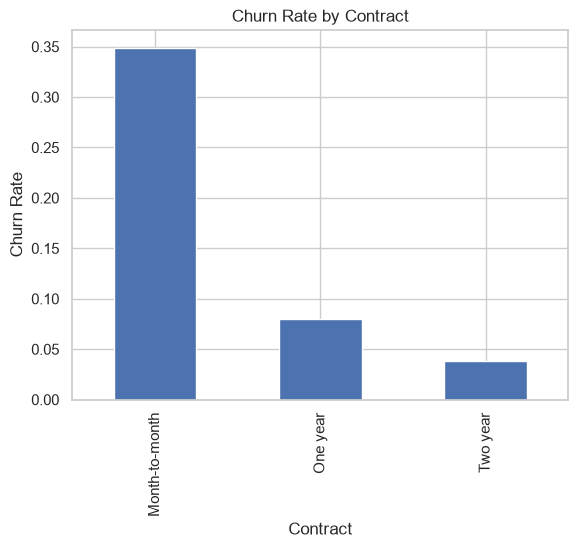

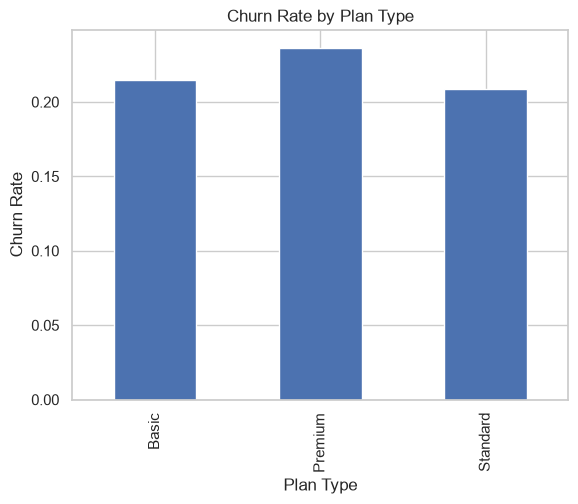

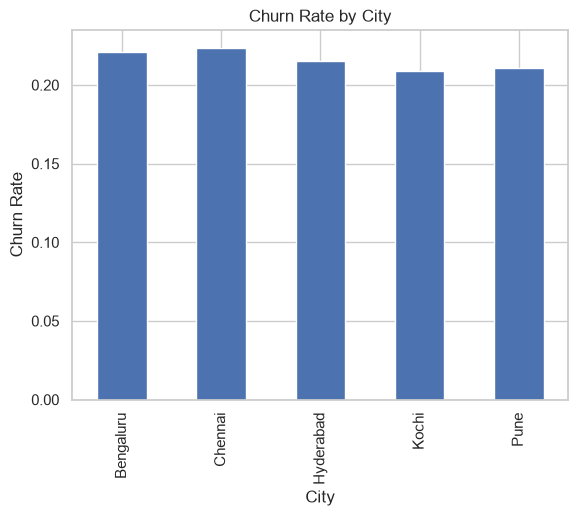

In [30]:
import matplotlib.pyplot as plt

# Contract
contract_churn.plot(kind="bar")
plt.title("Churn Rate by Contract")
plt.ylabel("Churn Rate")
plt.xlabel("Contract")
plt.show()

# Plan type
plan_churn.plot(kind="bar")
plt.title("Churn Rate by Plan Type")
plt.ylabel("Churn Rate")
plt.xlabel("Plan Type")
plt.show()

# City
city_churn.plot(kind="bar")
plt.title("Churn Rate by City")
plt.ylabel("Churn Rate")
plt.xlabel("City")
plt.show()

*Reading:*

About 21.85% of customers have churned. Churn is much higher for month-to-month customers (35.22%) than for customers with longer contracts. Churn rates across plans are quite similar, while Chennai has the highest city-level churn (26.83%) in the current data. Overall, contract type has the clearest difference in churn.

### Q2. Which numbers differ between churners and stayers?
For each numeric column: mean for churners vs stayers, Cohen's d, and a test (shuffle or `ttest_ind`). Rank by |d|. **Reading:** which two numbers matter most, and which is noise?

In [21]:
# YOUR CODE HERE
# Hint: for each numeric col: means, Cohen's d, ttest_ind; DataFrame sorted by |d|; two boxplots
import pandas as pd
from scipy.stats import ttest_ind

# Numeric columns
columns = ["age", "tenure_months", "monthly_charges","total_charges", "support_calls"]
results = []

for col in columns:

    # Get values for churners and stayers
    churners = raw[raw["churned"] == 1][col].dropna()
    stayers = raw[raw["churned"] == 0][col].dropna()

    # Calculate means
    churner_mean = churners.mean()
    stayer_mean = stayers.mean()

    # Calculate Cohen's d
    pooled_std = ((churners.std() ** 2 + stayers.std() ** 2) / 2) ** 0.5
    cohens_d = (churner_mean - stayer_mean) / pooled_std

    # Perform t-test
    t_stat, p_value = ttest_ind(churners, stayers, equal_var=False)

    # Store results
    results.append([col, churner_mean, stayer_mean, cohens_d, p_value])

# Create table
results = pd.DataFrame(
    results,
    columns=[ "Column", "Churner Mean", "Stayer Mean", "Cohen's d", "p-value" ])

# Rank by Cohen's d
results["Absolute d"] = results["Cohen's d"].abs()
results = results.sort_values("Absolute d", ascending=False)
print(results)


            Column  Churner Mean   Stayer Mean  Cohen's d        p-value  \
1    tenure_months     17.910430     29.676400  -0.722164  5.094649e-140   
3    total_charges  16939.041460  27869.627673  -0.633675  1.328133e-109   
4    support_calls      1.602480      1.111426   0.435609   1.087738e-40   
2  monthly_charges    907.777060    916.472747  -0.025058   4.384332e-01   
0              age     47.752006     47.969262  -0.014194   6.414725e-01   

   Absolute d  
1    0.722164  
3    0.633675  
4    0.435609  
2    0.025058  
0    0.014194  


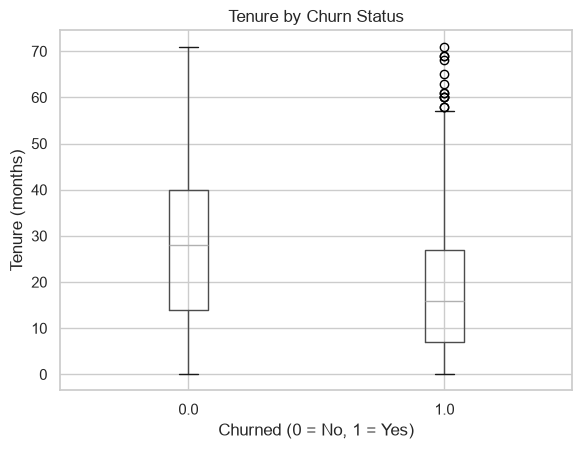

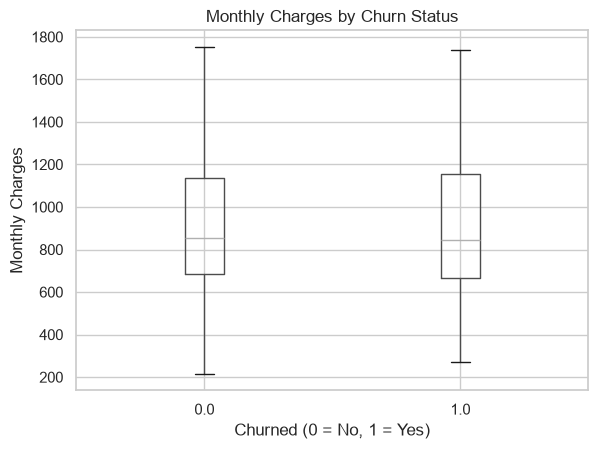

In [22]:
import matplotlib.pyplot as plt

raw.boxplot(column="tenure_months", by="churned")
plt.title("Tenure by Churn Status")
plt.suptitle("")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Tenure (months)")
plt.show()

raw.boxplot(column="monthly_charges", by="churned")
plt.title("Monthly Charges by Churn Status")
plt.suptitle("")
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Monthly Charges")
plt.show()

*Reading:*

Tenure and total charges show the biggest differences between churners and stayers. Churners have shorter tenure and lower total charges, while they also make slightly more support calls. Age and monthly charges show very little difference, so they appear less important here.

### Q3. Which categories are associated with churn?
`pd.crosstab` per categorical column with churn rate per level, and `chi2_contingency` for the test. **Reading:** which category has the biggest spread in churn rate across its levels?

In [23]:
# YOUR CODE HERE
# Hint: pd.crosstab(df[col], df['churned']); chi2_contingency; churn rate spread per feature
import pandas as pd
from scipy.stats import chi2_contingency

# Categorical columns
columns = ["gender", "plan_type", "contract", "payment_method", "has_broadband", "has_streaming", "city"]
results = []

for col in columns:

    # Create a table
    table = pd.crosstab(raw[col], raw["churned"])

    # Calculate churn rate
    churn_rate = raw.groupby(col)["churned"].mean()

    # Find highest and lowest churn rate
    highest = churn_rate.max()
    lowest = churn_rate.min()

    # Calculate the spread
    spread = highest - lowest

    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(table)

    # Save the result
    results.append([col, spread, p_value])

# Make a DataFrame
results = pd.DataFrame(results,columns=["Feature", "Churn Rate Spread", "p-value"])

# Sort from biggest spread to smallest
results = results.sort_values( "Churn Rate Spread", ascending=False)
print(results)

          Feature  Churn Rate Spread        p-value
2        contract           0.310693  4.829516e-168
3  payment_method           0.088332   1.747020e-07
4   has_broadband           0.061330   7.348595e-09
1       plan_type           0.027529   1.350143e-01
6            city           0.015025   9.109004e-01
0          gender           0.009129   3.956478e-01
5   has_streaming           0.008547   4.509133e-01


*Reading:*

Contract has the biggest churn-rate spread (31.42%), making it the clearest category associated with churn. Payment method and broadband also show some differences, while gender and streaming have very small spreads.

### Q4. Churn by tenure cohort
Bins 0–6, 7–12, 13–24, 25+ months. Bar chart of churn rate per cohort. **Reading:** when is the customer most at risk, and what does that say about onboarding?

Churn rate by tenure cohort:
tenure_cohort
0-6 months      0.362431
7-12 months     0.306971
13-24 months    0.262585
25+ months      0.133959
Name: churned, dtype: float64


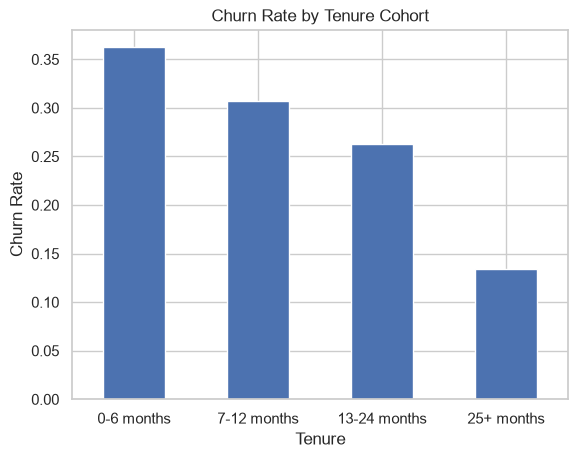

In [25]:
# YOUR CODE HERE
# Hint: pd.cut(tenure, bins=[0,6,12,24,999]); groupby cohort churn rate; barplot
import pandas as pd
import matplotlib.pyplot as plt

# Create tenure groups
raw["tenure_cohort"] = pd.cut(
    raw["tenure_months"],
    bins=[0, 6, 12, 24, 999],
    labels=["0-6 months", "7-12 months", "13-24 months", "25+ months"]
)

# Calculate churn rate for each group
cohort_churn = raw.groupby("tenure_cohort", observed=False)["churned"].mean()

# Print churn rates
print("Churn rate by tenure cohort:")
print(cohort_churn)

# Create bar chart
cohort_churn.plot(kind="bar")

plt.title("Churn Rate by Tenure Cohort")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate")
plt.xticks(rotation=0)
plt.show()

*Reading:*

Churn is highest in the first 6 months (36.51%) and gradually decreases as customers stay longer. This suggests that early onboarding and the initial customer experience are important areas to focus on.

---
## Session 3 — Q5, Q6, the brief

### Q5. The highest-risk profile, in plain English
Combine the top findings into one segment (e.g. month-to-month + tenure ≤ 6 + 2+ support calls). Report its size, its churn rate, and how many churners it accounts for. **Reading:** is it where the retention budget should go?

In [26]:
# Find the highest-risk group
high_risk = raw[
    (raw["contract"] == "Month-to-month") &
    (raw["tenure_months"] <= 6) &
    (raw["support_calls"] >= 2)
]

# Number of customers in this group
group_size = len(high_risk)

# Churn rate
churn_rate = high_risk["churned"].mean()

# Number of churners
churners = high_risk["churned"].sum()

# Percentage of all churners represented by this group
all_churners = raw["churned"].sum()
churner_share = churners / all_churners

print("High-risk group size:", group_size)
print("High-risk churn rate:", churn_rate)
print("Number of churners:", churners)
print("Share of all churners:", churner_share)

High-risk group size: 264
High-risk churn rate: 0.5943775100401606
Number of churners: 148.0
Share of all churners: 0.10795040116703136


*Reading:*

This high-risk group has 264 customers, with a 59.44% churn rate. It includes 148 churners, accounting for about 10.8% of all churners. This makes the group a clear area to consider when planning retention efforts.

### Q6. Your own question
Options: does churn rise with monthly charges *within* a plan? · are support calls a cause or a symptom (do they rise with tenure)? · payment method × contract interaction · streaming add-on and retention · city differences after controlling for contract mix.

Average monthly charges by plan and churn:
plan_type  churned
Basic      0.0         633.727173
           1.0         603.059063
Premium    0.0        1436.184405
           1.0        1405.219931
Standard   0.0         929.980248
           1.0         918.436404
Name: monthly_charges, dtype: float64

Churn rate by plan:
plan_type
Basic       0.214596
Premium     0.236527
Standard    0.208998
Name: churned, dtype: float64


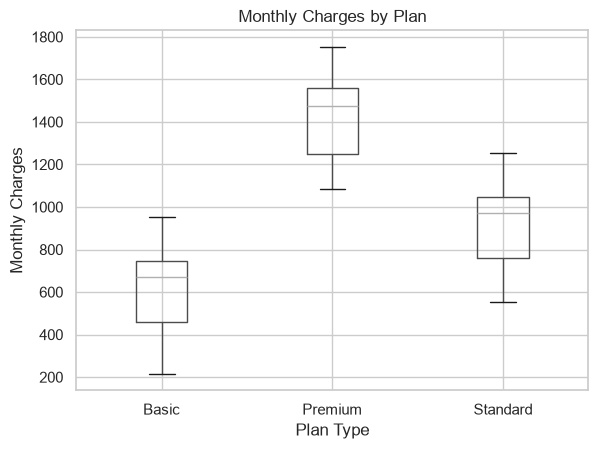

In [ ]:
# YOUR CODE HERE
# Hint: your question, your code
###Does churn rise with monthly charges within each plan?
import pandas as pd
import matplotlib.pyplot as plt

# Check average monthly charges for churners and stayers
result = raw.groupby(["plan_type", "churned"])["monthly_charges"].mean()
print("Average monthly charges by plan and churn:")
print(result)

# Churn rate by plan
churn_by_plan = raw.groupby("plan_type")["churned"].mean()
print("\nChurn rate by plan:")
print(churn_by_plan)

# Create boxplot
raw.boxplot(column="monthly_charges", by="plan_type")

plt.title("Monthly Charges by Plan")
plt.suptitle("")
plt.xlabel("Plan Type")
plt.ylabel("Monthly Charges")
plt.show()

### The one-page churn brief (for the VP)
Structure: **Situation** (2 lines) → **Three findings**, each with the number → **Recommendation** (where the budget goes, what to change) → **Confidence** (one line: what you'd need to be surer).

> *Your brief here — 250–350 words.*

**Situation**

Overall churn is 21.85%, meaning about 1 in 5 customers leave. The biggest differences are seen in contract type and customer tenure.

**Three Findings**

Contract: Month-to-month customers have the highest churn at 35.22%, compared with 3.79% for two-year contracts.

Tenure: Customers in their first 6 months have a 36.51% churn rate, which drops to 13.35% for customers with 25+ months.

High-risk group: Month-to-month customers with ≤6 months of tenure and 2+ support calls have a 59.44% churn rate.

**Recommendation**

Focus retention efforts on new month-to-month customers, especially those who contact support frequently. Better onboarding and early follow-ups could help reduce churn.

### Cliffhanger
You can describe who churned. The VP asks: "Which of the current 5,400 customers will churn next quarter?" — Module 20, on this exact file.